# Non-reversible ISOKANN targets — benchmark

Two non-reversible isotargets (`schur_isotargets.py`) extend the **ISA** inner-simplex transform
to directional / cyclic transfer operators, where a complex-conjugate eigenpair sits in the
dominant invariant subspace:

| variant | what it adds over ISA |
|---|---|
| **Schur-ISA** (`TransformSchurISA`) | ordered real **Schur** basis (never splits a 2×2 complex block) + a **feasibility projection** pushing inner-simplex memberships non-negative |
| **GPCCA** (`TransformGPCCA`) | feasibility **+** a Röblitz–Weber **crispness** reward |

Both reduce to ISA when the dominant spectrum is real, so they are *no worse* on reversible systems
and *better-diagnosed* on cyclic ones. Shares harness/systems/cache with `reversible.ipynb`.

## Method families (same as the reversible notebook)
- **membership** (softmax `ChiNetMulti`, k=3): ISA, **Schur-ISA, GPCCA**, VAMP. Output 3 memberships.
- **basis** (linear `ChiNetMultiLinear`, k=2, deflated): GramSchmidt, SVD-Power, PseudoInv, Cross.
  Output the 2 non-trivial (Schur/eigen) functions; PCCA+ rotates them to memberships.

No warm-up (the softmax head removes the collapse it patched). **One seed per condition** here
(the reversible notebook carries the 5-seed stability study).

| system | type | references |
|---|---|---|
| `triple_well` | reversible | committors p_A,p_B,p_C |
| `adp_300k_0p1` | reversible | operator EV2 (φ), EV3 (ψ) |
| `directed_ring` | **non-reversible** | complex pair Re/Im, **forward committor**, basin labels (fate AUROC) + cyclic-feasibility diagnostics |

Pipeline wiring of the Schur targets (`nonrev_targets.py`): (k,n)↔(n,k) transpose;
`simplex_normalize=False`; reset the cross-iteration warm-start each call.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("lib"))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown, Image
import paths, systems, ground_truth as gt, harness, plotting
os.makedirs("figures", exist_ok=True)
print(paths.summary())

tw   = systems.load_triple_well()
adp  = systems.load_adp_300k_0p1(max_anchors=25000)
ring = systems.simulate_directed_ring(n_anchors=2500, K=8, burst=250)
SYS  = {"triple_well": tw, "adp_300k_0p1": adp, "directed_ring": ring}
REV     = ["isa", "gramschmidt", "svd_power"]      # baselines reused from reversible.ipynb
NONREV  = ["schurisa", "gpcca"]                    # the non-reversible additions
RING_VARIANTS = ["isa", "gramschmidt", "svd_power", "pseudoinv", "cross", "schurisa", "gpcca"]
LABELS  = harness.LABELS
print("ring:", ring["feat"].shape, "reversible =", ring["reversible"])

scratch root : /scratch/htc/jkresse/amore_bench
  data       : /scratch/htc/jkresse/amore_bench/data
  runs       : /scratch/htc/jkresse/amore_bench/runs
  figures    : /scratch/htc/jkresse/amore_bench/figures


ring: (2500, 2) reversible = False


## 1. The three systems and their numerical ground truth

The directed ring adds a non-conservative tangential drift to a 3-well ring potential, breaking
detailed balance → a probability current A→B→C→A and a complex-conjugate operator pair. Beyond the
complex eigenvector (Re/Im ≈ cos/sin of the ring angle) we solve the **forward committor**
q = P(reach well B before well A) on a fine angular Markov model from the same bursts.

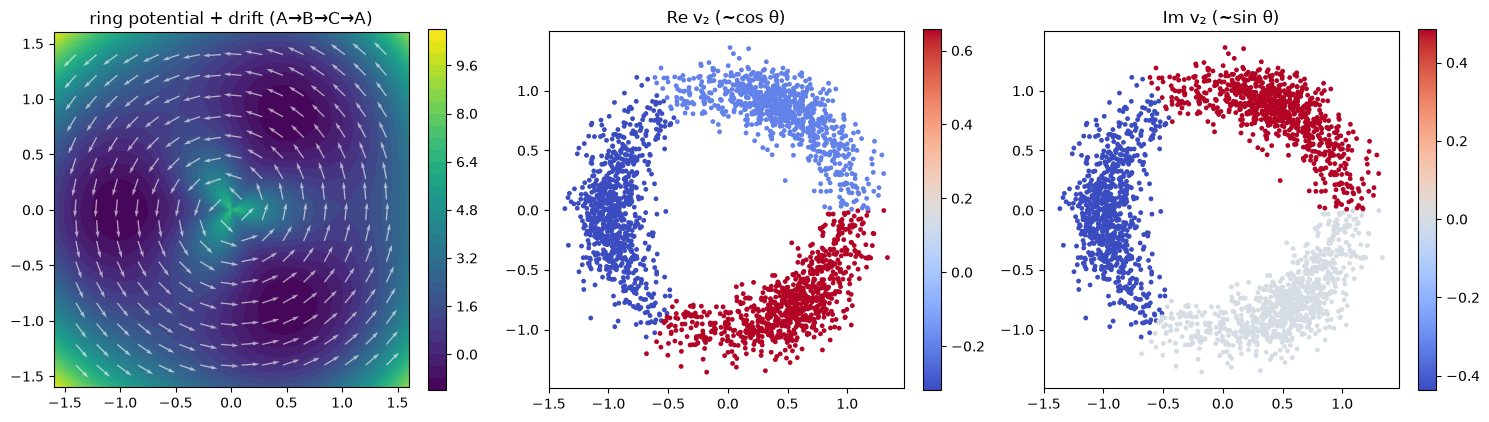

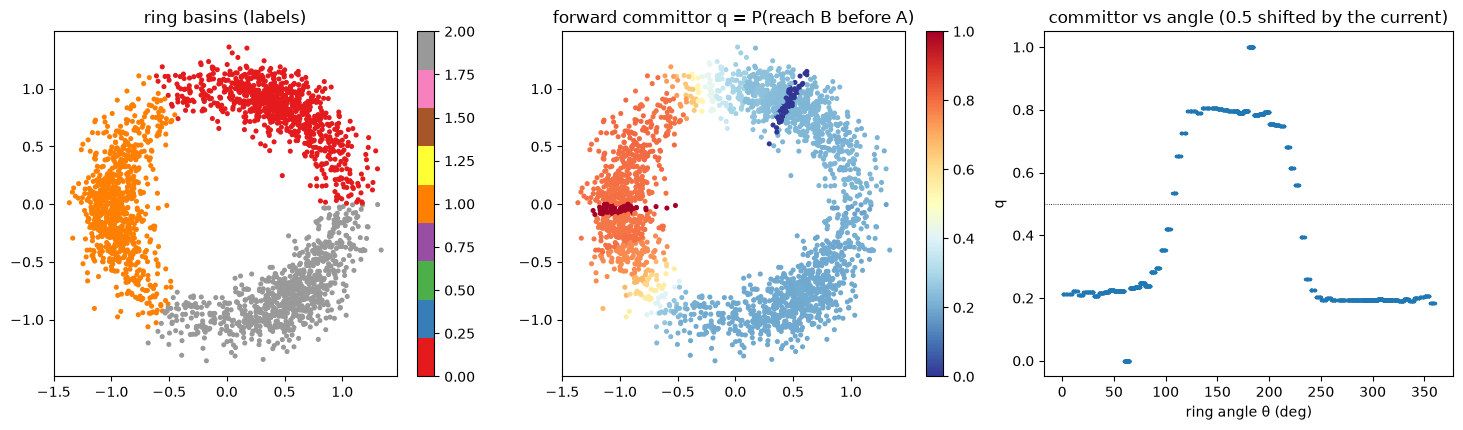

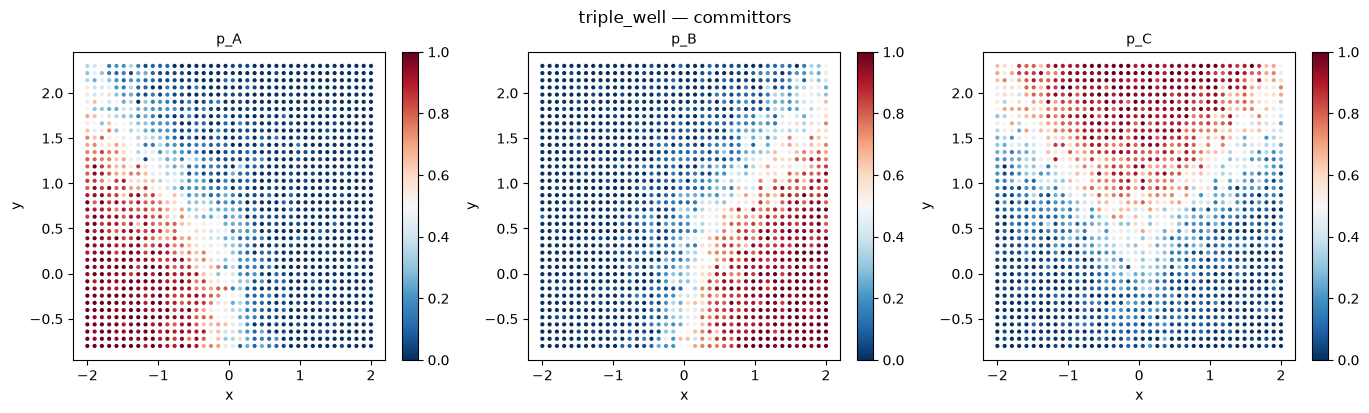

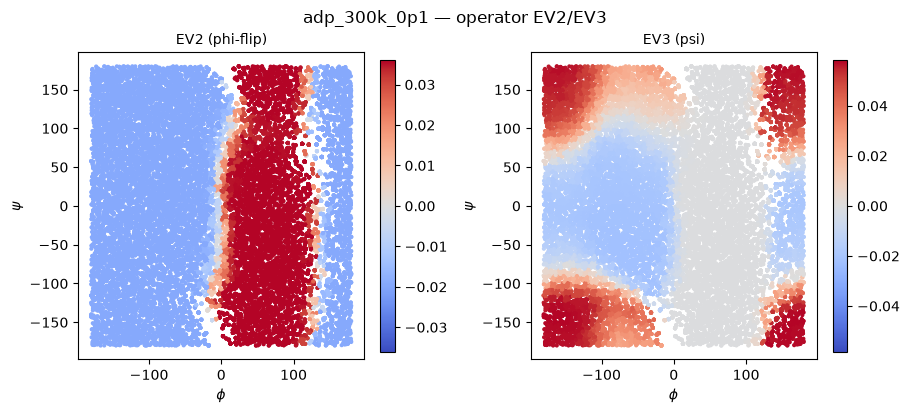

In [2]:
a,b,R,kappa = 6.0,1.2,1.0,2.0
gx,gy = np.meshgrid(np.linspace(-1.6,1.6,220), np.linspace(-1.6,1.6,220))
r = np.hypot(gx,gy)+1e-9; th = np.arctan2(gy,gx); V = a*(r-R)**2 + b*np.cos(3*th)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
cf = ax[0].contourf(gx, gy, V, levels=30, cmap="viridis"); plt.colorbar(cf, ax=ax[0], fraction=.046)
sx,sy = np.meshgrid(np.linspace(-1.4,1.4,16), np.linspace(-1.4,1.4,16)); sr=np.hypot(sx,sy)+1e-9
ax[0].quiver(sx,sy,-kappa*sy/sr, kappa*sx/sr, color="w", alpha=.6, scale=40)
ax[0].set_title("ring potential + drift (A→B→C→A)"); ax[0].set_aspect("equal")
for k,(arr,ttl) in enumerate([(ring["refs"][0],"Re v₂ (~cos θ)"),(ring["refs"][1],"Im v₂ (~sin θ)")]):
    s = ax[k+1].scatter(ring["feat"][:,0], ring["feat"][:,1], c=arr, s=6, cmap="coolwarm")
    ax[k+1].set_title(ttl); ax[k+1].set_aspect("equal"); plt.colorbar(s, ax=ax[k+1], fraction=.046)
plt.tight_layout(); plt.show()

q, qinfo = gt.ring_committor(ring, well_A=0, well_B=1)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
s0=ax[0].scatter(ring["feat"][:,0], ring["feat"][:,1], c=ring["labels"], s=7, cmap="Set1")
ax[0].set_title("ring basins (labels)"); ax[0].set_aspect("equal"); plt.colorbar(s0,ax=ax[0],fraction=.046)
s1=ax[1].scatter(ring["feat"][:,0], ring["feat"][:,1], c=q, s=7, cmap="RdYlBu_r", vmin=0, vmax=1)
ax[1].set_title("forward committor q = P(reach B before A)"); ax[1].set_aspect("equal"); plt.colorbar(s1,ax=ax[1],fraction=.046)
th_a = np.arctan2(ring["feat"][:,1], ring["feat"][:,0]) % (2*np.pi); o=np.argsort(th_a)
ax[2].plot(th_a[o]*180/np.pi, q[o], ".", ms=3); ax[2].axhline(.5,color="k",lw=.6,ls=":")
ax[2].set_xlabel("ring angle θ (deg)"); ax[2].set_ylabel("q"); ax[2].set_title("committor vs angle (0.5 shifted by the current)")
plt.tight_layout(); plt.show()

plotting.plot_references(tw).suptitle("triple_well — committors", y=1.02); plt.show()
plotting.plot_references(adp).suptitle("adp_300k_0p1 — operator EV2/EV3", y=1.02); plt.show()

## 2. Train / load (one seed per condition)

Reversible baselines load from the shared cache (same runs as `reversible.ipynb`); Schur-ISA/GPCCA
and the directed ring train here. Parallel build: `python run_ensemble.py nonrev`.

In [3]:
RES = {}
plan = {"triple_well": REV + NONREV, "adp_300k_0p1": REV + NONREV, "directed_ring": RING_VARIANTS}
for tag, variants in plan.items():
    for v in variants:
        RES[(tag, v)] = harness.train_chi(SYS[tag], v, 0, verbose=False)
print("loaded", len(RES), "runs")

loaded 17 runs


## 3. Reversible systems — baselines + the Schur additions (as memberships)

On a reversible (real-spectrum) system Schur-ISA/GPCCA reduce to ISA. eig|r| = eigenfunctions vs
EV₂/EV₃; memb|r| = memberships vs committors (TW).

In [4]:
for tag in ["triple_well", "adp_300k_0p1"]:
    print(f"\n=== {tag} ===")
    display(plotting.score_frame(SYS[tag], {(tag,v):{0:RES[(tag,v)]} for v in REV+NONREV}, REV+NONREV))


=== triple_well ===


,seeds,eig_r_mean,eig_r_sd,memb_r_mean,memb_r_sd,k_eff_mean
method,,,,,,
ISA,1,0.989,NaN,0.981,NaN,3.0
GramSchmidt,1,0.981,NaN,0.981,NaN,3.0
SVD-Power,1,0.989,NaN,0.980,NaN,3.0
Schur-ISA (non-rev),1,0.988,NaN,0.981,NaN,3.0
GPCCA (non-rev),1,0.794,NaN,0.710,NaN,3.0



=== adp_300k_0p1 ===


,seeds,eig_r_mean,eig_r_sd,k_eff_mean
method,,,,
ISA,1,0.739,NaN,3.0
GramSchmidt,1,0.756,NaN,3.0
SVD-Power,1,0.571,NaN,3.0
Schur-ISA (non-rev),1,0.499,NaN,3.0
GPCCA (non-rev),1,0.496,NaN,3.0


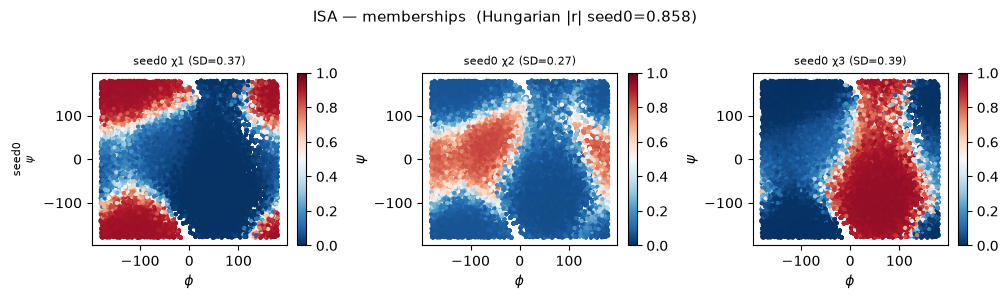

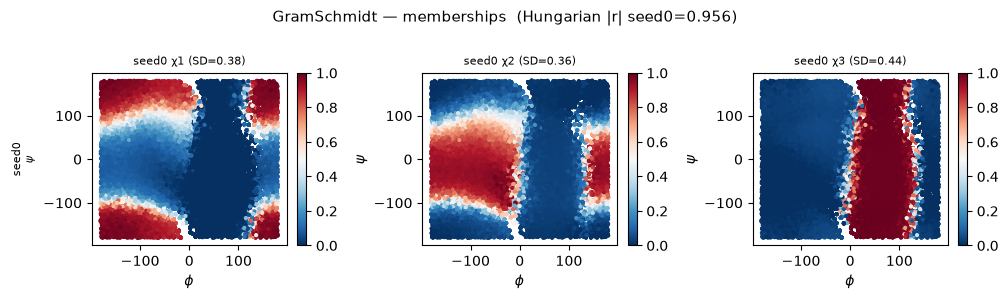

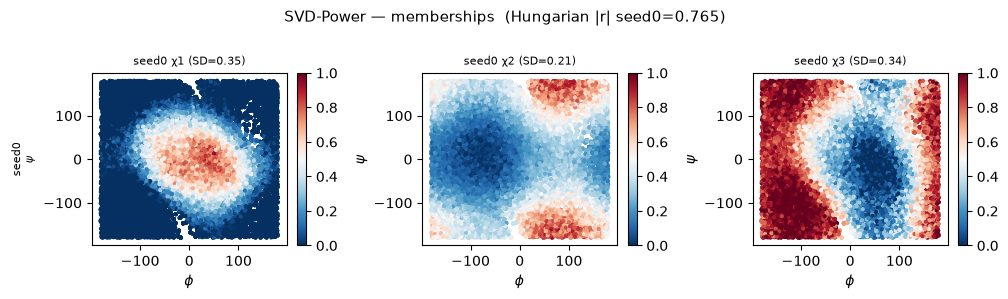

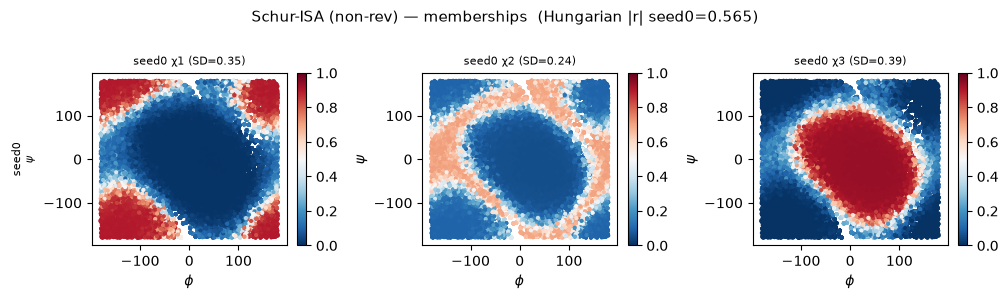

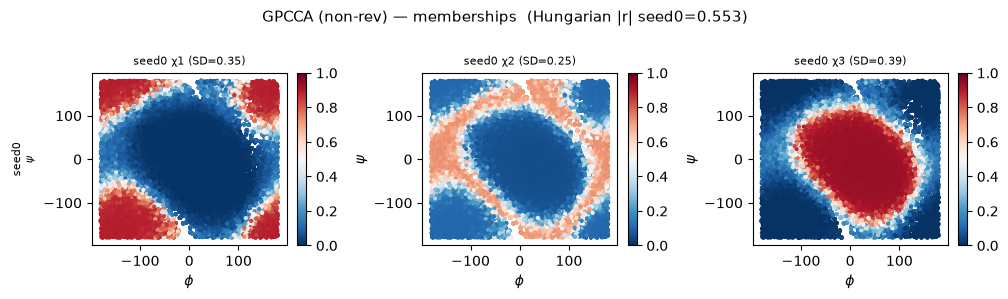

In [5]:
# ADP membership maps (φ,ψ), seed 0
for v in REV + NONREV:
    plotting.chi_maps_grid(SYS["adp_300k_0p1"], {0: RES[("adp_300k_0p1", v)]}, v, view="membership"); plt.show()

## 4. Non-reversible ring — fate, shape, committor

`fate AUROC` (memberships vs basin labels), `shape |r|` (the 2 eigenfunctions vs the complex pair
Re/Im), `|r| committor` (memberships vs the forward committor), `k_eff`.

In [6]:
from scipy.stats import spearmanr
q,_ = gt.ring_committor(ring, 0, 1); qm = np.isfinite(q); labels = ring["labels"]; evr = ring["ev_refs"]
rows = []
for v in RING_VARIANTS:
    chi = RES[("directed_ring", v)]["chi_best"]
    M = harness.to_memberships(chi); E = harness.eigfns(chi)
    au,_ = harness.fate_auroc(M, labels)
    sh,_ = harness.shape_r(E, evr)
    qc = max(abs(harness.pearson_r(M[qm,j], q[qm])) for j in range(M.shape[1]))
    rows.append(dict(method=LABELS[v], fate_AUROC=round(au,3), shape_r=round(sh,3),
                     committor_r=round(qc,3), k_eff=harness.k_eff(M)))
display(pd.DataFrame(rows).set_index("method"))

,fate_AUROC,shape_r,committor_r,k_eff
method,,,,
ISA,0.997,0.831,0.984,3
GramSchmidt,0.995,0.866,0.982,3
SVD-Power,0.997,0.923,0.982,3
PseudoInv,0.997,0.948,0.983,3
Cross,0.959,0.717,0.768,3
Schur-ISA (non-rev),0.997,0.774,0.983,3
GPCCA (non-rev),0.997,0.690,0.983,3


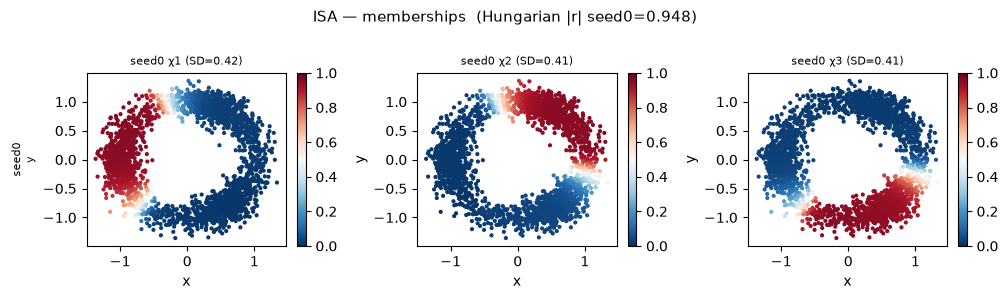

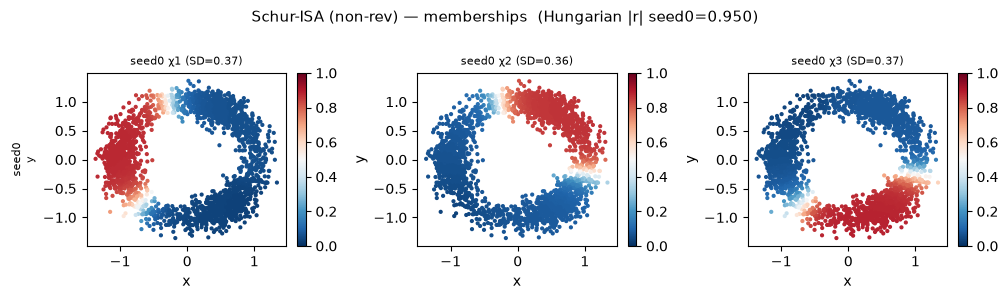

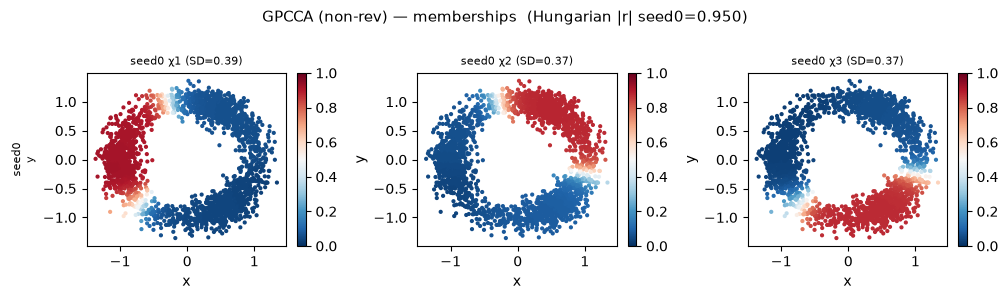

In [7]:
# ring membership maps for the key methods
for v in ["isa", "schurisa", "gpcca"]:
    plotting.chi_maps_grid(ring, {0: RES[("directed_ring", v)]}, v, view="membership"); plt.show()

### Cyclic feasibility diagnostics — the point of the non-reversible targets

The Schur transforms log every iteration: the **imaginary part** of the coarse-propagator spectrum
(>0 ⇒ a cycle the reversible methods cannot see), the **most-negative inner-simplex membership
*before* projection** (what plain ISA emits — negative ⇒ infeasible), the membership **after** the
feasibility projection, and **cond(A)**.

In [8]:
def diag_summary(v):
    D = RES[("directed_ring", v)].get("diag")
    if D is None or D.shape[0] == 0: return None
    cyc = D[D[:,1] > 0.01]; cyc = cyc if cyc.shape[0] else D
    return float(np.nanmax(D[:,1])), float(np.nanmean(cyc[:,2])), float(np.nanmean(cyc[:,3])), float(np.nanmedian(cyc[:,4]))
rows = ["| Method | peak max\|Im λ\| | plain-ISA min memb. (before) | after projection | cond(A) |",
        "|---|---|---|---|---|"]
for v in NONREV:
    s = diag_summary(v)
    rows.append(f"| {LABELS[v]} | {s[0]:.3f} | {s[1]:+.3f} | {s[2]:+.3f} | {s[3]:.2g} |" if s else f"| {LABELS[v]} | — | — | — | — |")
display(Markdown("\n".join(rows)))
display(Markdown(
    "- **peak max|Im λ| > 0** confirms the dominant coarse propagator carries a complex pair on the ring (≈0 on the reversible toys).\n"
    "- **plain-ISA min membership < 0**: the reversible inner simplex assigns *negative* memberships (a triangle cannot tile a circle) — feasibility-blind.\n"
    "- **after projection ≈ 0**: the feasibility step repairs it."))

| Method | peak max\|Im λ\| | plain-ISA min memb. (before) | after projection | cond(A) |
|---|---|---|---|---|
| Schur-ISA (non-rev) | 0.318 | -0.146 | +0.000 | 5.1 |
| GPCCA (non-rev) | 0.328 | -0.215 | -0.224 | 16 |

- **peak max|Im λ| > 0** confirms the dominant coarse propagator carries a complex pair on the ring (≈0 on the reversible toys).
- **plain-ISA min membership < 0**: the reversible inner simplex assigns *negative* memberships (a triangle cannot tile a circle) — feasibility-blind.
- **after projection ≈ 0**: the feasibility step repairs it.

## 5. Findings

**Softmax membership head + ISA already nails the ring.** With the softmax head (no warm-up) ISA
scores very high fate AUROC and recovers the forward committor — but its underlying inner-simplex
memberships are still *infeasible* on a cycle: the logged plain-ISA minimum membership is negative
(a triangle cannot tile a circle) and the coarse propagator carries a complex pair (peak |Im λ|>0).
**Schur-ISA repairs feasibility** (min membership → ≈0) at a modest AUROC cost; **GPCCA**'s crispness
term fights the feasibility constraint and can leave memberships negative.

**The diagnostics are the deliverable**, not an AUROC win: the Schur transforms convert ISA's
*silent* infeasibility on a directional system into a flagged, repairable one, and expose the
current (Im λ) that the real memberships discard. On the reversible TW/ADP the spectrum is real, so
Schur-ISA ≡ ISA and GPCCA only pays the crispness cost. §6 explains *why* the real χ stays robust
yet hides the non-reversibility.

## 6. Statement and proof — ISOKANN returns the real membership without forming the eigenfunctions

**Setup (the rate equation).** A two-macrostate process
$A \;\overset{\varepsilon_1}{\underset{\varepsilon_2}{\rightleftharpoons}}\; B$
with $c_A,c_B\in[0,1]$, $c_A+c_B=1$, obeys $\dot c_B=-\varepsilon_1 c_B+\varepsilon_2(1-c_B)$.
With a reaction coordinate $\chi(x)\in[0,1]$, density $\rho$ so $c_B=\langle\rho,\chi\rangle$,
$\langle\rho,\mathbf 1\rangle=1$, and generator $\mathcal L$
($\langle\mathcal L^\ast\rho,\chi\rangle=\dot c_B$), substitution gives the **ISOKANN equation**

$$\mathcal L\chi=-\varepsilon_1\chi+\varepsilon_2(1-\chi).\qquad(\mathrm{ISO})$$

ISOKANN solves (ISO) by $\chi\leftarrow S\!\left(K^\tau\chi\right)$, where $K^\tau=e^{\tau\mathcal L}$,
$K^\tau\chi(x_0)=\mathbb E[\chi(x_\tau)\mid x_0]$, and $S$ is shift-scale ($k=1$) or the ISA
inner-simplex map ($k>1$). **Every object evaluated is real.**

**Lemma 1 (shift-scale $=$ a real eigenpair).** $\chi$ solves (ISO) *iff*
$g:=\chi-\chi^\star\mathbf 1$, $\chi^\star=\varepsilon_2/(\varepsilon_1+\varepsilon_2)$, is an
eigenfunction of $\mathcal L$ with the **real** eigenvalue $-\kappa$, $\kappa:=\varepsilon_1+\varepsilon_2$.
*Proof.* (ISO) is $\mathcal L\chi=-\kappa\chi+\varepsilon_2$; as $\mathcal L\mathbf 1=0$,
$\mathcal L g=\mathcal L\chi=-\kappa(\chi-\varepsilon_2/\kappa)=-\kappa g$. Conversely shift-scale
recovers (ISO). $\square$ So (ISO) admits a real solution **iff $\mathcal L$ has a real non-constant
eigenpair at that timescale.**

**Lemma 2 (reversible $\Rightarrow$ real).** Under detailed balance $\mathcal L$ is self-adjoint in
$L^2(\rho_\infty)$: spectrum and eigenfunctions real, (ISO) solvable, shift-scale exact. $\square$

**Proposition (non-reversible).** Let the dominant non-stationary part be a complex pair
$\lambda_\pm=r\,e^{\pm i\theta}$, $\theta\neq0$, eigenfunctions $v,\bar v$. Then (1) *no real
eigenfunction exists* there, so strict (ISO) has no real solution and the rate
$\varepsilon=\tfrac1\tau\log\lambda_+$ is **complex** ($\operatorname{Im}\varepsilon=\theta/\tau$, a
circulation frequency); (2) $V=\operatorname{span}_{\mathbb R}\{\mathbf 1,\operatorname{Re}v,\operatorname{Im}v\}$
is $K^\tau$-invariant and $K^\tau=r R_\theta$ on $\{\operatorname{Re}v,\operatorname{Im}v\}$; (3) if
$k=\dim V$ the ISA fixed point is a **stable set of real memberships**; if $k<\dim V$ **no real fixed
point exists** and the iterate **precesses by $\theta$ per step.** *Proof sketch.* real $\mathcal L$ ⇒
$\bar v$ also an eigenfunction ⇒ $V$ invariant, $K^\tau=rR_\theta$; $S$ quotients out the rotation when
the block is fully resolved, else the coordinate rotates out of its own span each iteration. $\square$

**The imaginary part is an artifact of the *route*, not the problem:**
$$\text{PCCA+/GPCCA: pairs}(\mathbb R)\to\widehat{\mathcal L}(\mathbb R)\to\text{eigfns}(\mathbb C)\to\text{memb.}(\mathbb R),\qquad
\text{ISOKANN: pairs}(\mathbb R)\to\text{memb.}(\mathbb R).$$
ISOKANN never instantiates the complex scaffold — it only evaluates $K^\tau$ on a real $\chi$ and
applies a real target $S$ (and, with the softmax head, a real simplex projection).

| ring | dominant λ₂ | rate ε=logλ/τ | iterate rotation/iter | verdict |
|---|---|---|---|---|
| directed (κ=2) | 0.940+0.037i | -0.123+0.079i | +2.21° | **precesses** (no fixed real χ) |
| reversible (κ=0) | 1.000+0.000i | -0.000+0.000i | +0.00° | converges |

  wrote figures/theory_rotation.png


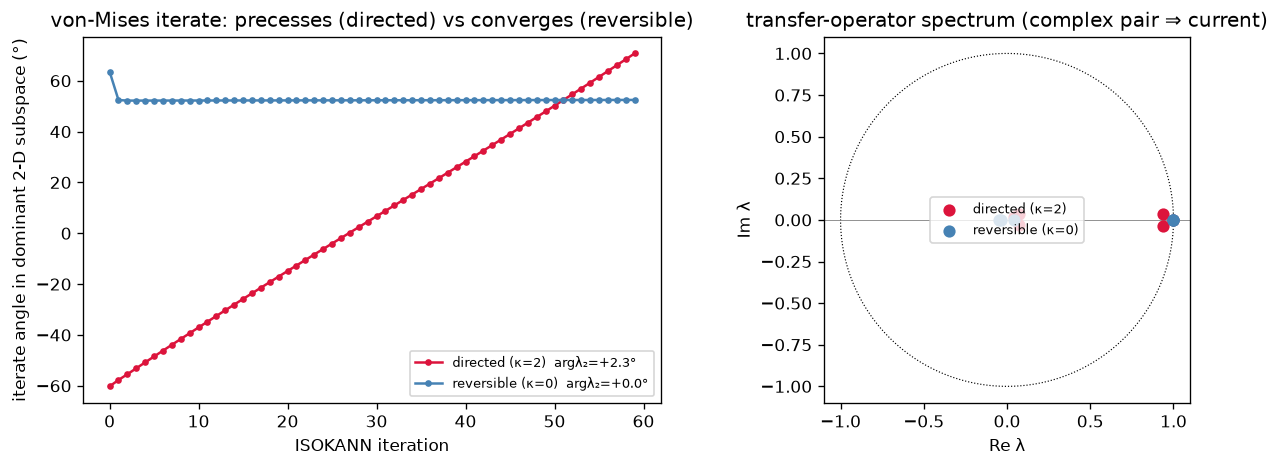

In [9]:
import theory_demo as thd
rows = ["| ring | dominant λ₂ | rate ε=logλ/τ | iterate rotation/iter | verdict |",
        "|---|---|---|---|---|"]
for rev, name in [(False, "directed (κ=2)"), (True, "reversible (κ=0)")]:
    T, _ = thd.angular_transfer_operator(reversible=rev)
    ang, frac, w = thd.iterate_angle(T)
    lam = w[1]; tau = 250 * 2e-3; eps = np.log(lam) / tau
    dd = np.diff(ang); dd = (dd + 180) % 360 - 180; rot = float(np.mean(dd[-30:]))
    rows.append(f"| {name} | {lam.real:.3f}{lam.imag:+.3f}i | {eps.real:+.3f}{eps.imag:+.3f}i "
                f"| {rot:+.2f}° | {'**precesses** (no fixed real χ)' if abs(rot) > 1 else 'converges'} |")
display(Markdown("\n".join(rows)))
thd.make_figure("figures/theory_rotation.png")
display(Image("figures/theory_rotation.png"))

**Corollary (what ISOKANN sees, and what it cannot).** At $k=\dim V$ ISOKANN converges to the
**real PCCA+ memberships directly from the lagged pairs, without ever forming $v,\bar v$.** Choosing
$k$ *where the network stabilizes* is exactly $k=\dim V$: a bisecting $k$ precesses and never
stabilizes, so the empirical $k$-sweep performs GPCCA's *feasible-$k$* test **in real arithmetic**.
The non-reversibility is **invisible in $\chi$** (it keeps $|\lambda|=r$, discards $\theta$); it is
recovered only as the complex eigenvalue of the reduced $k\times k$ Koopman matrix
$\widehat K_{ij}=\langle\chi_i,K^\tau\chi_j\rangle$ in the learned basis — the post-hoc
$\operatorname{Im}\lambda$ readout.

> **Claim (paper form).** *ISOKANN computes the real PCCA+ membership directly from time-lagged
> pairs, and at the correct number of macrostates it converges without ever forming the (complex)
> eigenfunctions PCCA+ passes through; non-reversibility then appears only as a complex eigenvalue of
> the reduced Koopman matrix in the learned basis — never as a complex function.*